# Lecture 05 — ML Security and Abuse Pathways

#**Natchapa Aunkay**
## Live Coding: Full Adversarial Attack Pipelines on COMPAS

## AI Assistance Disclosure - Generative AI (ChatGPT) was used to support code formatting, debugging, and improving the clarity of written explanations. All modeling decisions, interpretation of results, and final conclusions were independently developed and verified by my own.

**Instructor:** Dr. Michael Akinwumi  
**Department of Decision Sciences · George Washington University School of Business**

---

This notebook continues directly from `Lecture-04-generalization.ipynb`.  
Dataset: [ProPublica COMPAS Analysis](https://github.com/propublica/compas-analysis)

### Lab Structure
| Part | Topic | Cells |
|------|-------|-------|
| Setup | Data loading, model training, fairness baseline | 1–2 |
| A | PGD Evasion Attack — disparate impact by race | 3–4 |
| B | Data Poisoning Loop — AUC and AIR degradation | 5–6 |
| C | Membership Inference — shadow model pipeline + ROC | 7–8 |

**Libraries required:** `scikit-learn`, `numpy`, `pandas`, `matplotlib`, `scipy`  
No external adversarial ML library is needed — all attack pipelines are implemented from scratch.

**NIST Reference:** Vassilev et al. (2024). *Adversarial Machine Learning: A Taxonomy and Terminology of Attacks and Mitigations.* NIST AI 100-2e2023. https://doi.org/10.6028/NIST.AI.100-2e2023

---
## Setup · Cell 1: Imports, Data Loading, and Model Training

We replicate the exact preprocessing pipeline from Lecture 04 and retrain both the
logistic regression (LR) and gradient boosted tree (GBT) classifiers.

**Threat modeling reminder (NIST AI 100-2, §2.1):**  
Before testing any attack, specify: *Who is the adversary? What do they know?
What can they control? What is their goal?*

In [1]:
# ── Cell 1: Imports, Data Loading, Model Training ─────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# ── Load COMPAS dataset (ProPublica) ──────────────────────────────────────────
URL = (
    "https://raw.githubusercontent.com/propublica/compas-analysis"
    "/master/compas-scores-two-years.csv"
)
df = pd.read_csv(URL)
print(f"Raw dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

# ── Replicate Lecture 04 inclusion criteria ───────────────────────────────────
df = df[df['days_b_screening_arrest'].between(-30, 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
print(f"After filtering: {df.shape[0]:,} rows")

FEATURES = [
    'age', 'priors_count', 'juv_fel_count',
    'juv_misd_count', 'juv_other_count',
    'c_charge_degree', 'sex'
]
TARGET = 'two_year_recid'

df_m = df[FEATURES + [TARGET, 'race']].dropna()
df_m = pd.get_dummies(df_m, columns=['c_charge_degree', 'sex'], drop_first=True)

X    = df_m.drop(columns=[TARGET, 'race']).astype(float)
y    = df_m[TARGET].values
race = df_m['race'].values

print(f"\nFeatures used: {list(X.columns)}")
print(f"Class balance: {y.mean():.1%} recidivism rate")

# ── Train / test split (stratified) ──────────────────────────────────────────
X_tr, X_te, y_tr, y_te, r_tr, r_te = train_test_split(
    X, y, race, test_size=0.3, random_state=42, stratify=y
)

sc    = StandardScaler()
Xs_tr = sc.fit_transform(X_tr)
Xs_te = sc.transform(X_te)

# ── Train models ──────────────────────────────────────────────────────────────
lr  = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr)
gbt = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, random_state=42
).fit(Xs_tr, y_tr)

print(f"\nLR  Test AUC: {roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1]):.3f}")
print(f"GBT Test AUC: {roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:,1]):.3f}")
print(f"LR  Train AUC: {roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:,1]):.3f}")
print(f"GBT Train AUC: {roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:,1]):.3f}")

Raw dataset: 7,214 rows, 53 columns
After filtering: 6,172 rows

Features used: ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree_M', 'sex_Male']
Class balance: 45.5% recidivism rate

LR  Test AUC: 0.735
GBT Test AUC: 0.718
LR  Train AUC: 0.727
GBT Train AUC: 0.798


---
## Setup · Cell 2: Clean-Model Fairness Baseline

Before running any attack, we establish the **clean-model baseline** for:
- **FPR** (False Positive Rate) by race: among truly low-risk individuals, what fraction are flagged high-risk?
- **AIR** (Adverse Impact Ratio): FPR of protected group / FPR of reference group

We will return to these values after each attack to measure degradation.

> **Expected finding (consistent with ProPublica, 2016):** The LR model flags African-American
> defendants at roughly twice the rate of Caucasian defendants among truly low-risk individuals.

In [2]:
# ── Cell 2: Clean-Model Fairness Baseline ─────────────────────────────────────

THR = 0.5  # classification threshold

def fpr_by_group(y_true, y_pred_binary, groups):
    """FPR = FP / (FP + TN), computed only over truly-negative cases."""
    mask = (y_true == 0)
    return (
        pd.DataFrame({'pred': y_pred_binary[mask], 'group': groups[mask]})
          .groupby('group')['pred']
          .mean()
    )

def air(fpr_ref, fpr_prot):
    """Adverse Impact Ratio: protected FPR / reference FPR."""
    return fpr_prot / fpr_ref if (fpr_ref is not None and fpr_ref > 0) else np.nan

# ── Compute baseline predictions ──────────────────────────────────────────────
pred_lr_clean  = (lr.predict_proba(Xs_te)[:,1]  >= THR).astype(int)
pred_gbt_clean = (gbt.predict_proba(Xs_te)[:,1] >= THR).astype(int)

print("=" * 60)
print("CLEAN MODEL BASELINE — Before Any Attack")
print("=" * 60)

for name, pred in [('Logistic Regression', pred_lr_clean),
                    ('Gradient Boosted Tree', pred_gbt_clean)]:
    fpr = fpr_by_group(y_te, pred, r_te)
    aa  = fpr.get('African-American', np.nan)
    ca  = fpr.get('Caucasian',        np.nan)
    print(f"\n{name}")
    print(f"  FPR African-American : {aa:.3f}")
    print(f"  FPR Caucasian        : {ca:.3f}")
    print(f"  AIR (AA / CA)        : {air(ca, aa):.3f}")

# Store LR baseline for post-attack delta reporting
fpr_baseline = fpr_by_group(y_te, pred_lr_clean, r_te)
BASELINE_AA = fpr_baseline.get('African-American')
BASELINE_CA = fpr_baseline.get('Caucasian')
BASELINE_AIR = air(BASELINE_CA, BASELINE_AA)

print(f"\n→ Baseline LR AIR stored: {BASELINE_AIR:.3f}")
print("  We will compare all attack outcomes against these values.")

CLEAN MODEL BASELINE — Before Any Attack

Logistic Regression
  FPR African-American : 0.281
  FPR Caucasian        : 0.143
  AIR (AA / CA)        : 1.961

Gradient Boosted Tree
  FPR African-American : 0.317
  FPR Caucasian        : 0.178
  AIR (AA / CA)        : 1.782

→ Baseline LR AIR stored: 1.961
  We will compare all attack outcomes against these values.


---
## Part A · Cell 3: PGD Evasion Attack

**Attack class (NIST AI 100-2, §2.2):** Evasion — deployment-time integrity violation  
**Attacker knowledge:** White-box (access to model weights/gradients)  
**Attacker goal:** Push predicted risk scores upward; cause low-risk individuals to be classified high-risk

### Algorithm: Projected Gradient Descent (Madry et al., 2018)

$$\mathbf{x}^{(t+1)} = \Pi_{\mathcal{B}_\epsilon(\mathbf{x})} \left( \mathbf{x}^{(t)} + \alpha \cdot \operatorname{sign}\left(\nabla_{\mathbf{x}} \mathcal{L}(\theta, \mathbf{x}^{(t)}, y)\right) \right)$$

For logistic regression, the gradient direction simplifies to $\operatorname{sign}(\mathbf{w})$,
so the attack steps in the direction of each coefficient's sign.

**$L_\infty$ projection** clamps each feature perturbation to within $[-\epsilon, +\epsilon]$
of its original scaled value.

In [3]:
# ── Cell 3: PGD Evasion Attack for LR and GBT ────────────────────────────────

def pgd_lr(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=40):
    coef = model.coef_[0]
    X_adv = X_scaled.copy()

    for _ in range(n_iter):
        X_adv = X_adv + alpha * np.sign(coef)[np.newaxis, :]
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)

    return X_adv


def pgd_score_based(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=20, h=1e-3):
    """
    Score-based PGD approximation for non-linear models like GBT.
    Uses finite-difference gradients on predicted probability.
    """
    X_adv = X_scaled.copy()
    n, d = X_adv.shape

    for _ in range(n_iter):
        grad = np.zeros_like(X_adv)

        for j in range(d):
            X_plus = X_adv.copy()
            X_minus = X_adv.copy()

            X_plus[:, j] += h
            X_minus[:, j] -= h

            p_plus = model.predict_proba(X_plus)[:, 1]
            p_minus = model.predict_proba(X_minus)[:, 1]

            grad[:, j] = (p_plus - p_minus) / (2 * h)

        X_adv = X_adv + alpha * np.sign(grad)
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)

    return X_adv

In [4]:
# ── Run PGD sweep for both LR and GBT ─────────────────────────────────────────

epsilons = [0.0, 0.25, 0.5, 1.0, 2.0]
pgd_records = []

for model_name, model in [('LR', lr), ('GBT', gbt)]:
    for eps in epsilons:

        if eps == 0.0:
            X_adv = Xs_te
        elif model_name == 'LR':
            X_adv = pgd_lr(model, Xs_te, epsilon=eps, alpha=0.05, n_iter=40)
        else:
            X_adv = pgd_score_based(model, Xs_te, epsilon=eps, alpha=0.05, n_iter=20)

        pred_adv = (model.predict_proba(X_adv)[:, 1] >= THR).astype(int)
        fpr_adv = fpr_by_group(y_te, pred_adv, r_te)

        aa = fpr_adv.get('African-American', np.nan)
        ca = fpr_adv.get('Caucasian', np.nan)

        pgd_records.append({
            'model': model_name,
            'epsilon': eps,
            'FPR_African_American': aa,
            'FPR_Caucasian': ca,
            'AIR_AA_over_CA': air(ca, aa)
        })

df_pgd = pd.DataFrame(pgd_records)
print(df_pgd.round(3).to_string(index=False))

model  epsilon  FPR_African_American  FPR_Caucasian  AIR_AA_over_CA
   LR     0.00                 0.281          0.143           1.961
   LR     0.25                 0.569          0.370           1.535
   LR     0.50                 0.791          0.560           1.411
   LR     1.00                 0.978          0.884           1.106
   LR     2.00                 1.000          1.000           1.000
  GBT     0.00                 0.317          0.178           1.782
  GBT     0.25                 0.317          0.178           1.782
  GBT     0.50                 0.317          0.178           1.782
  GBT     1.00                 0.317          0.178           1.782
  GBT     2.00                 0.317          0.178           1.782


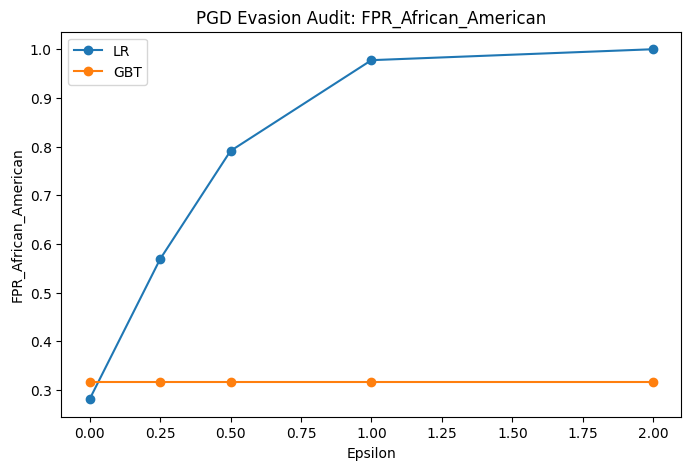

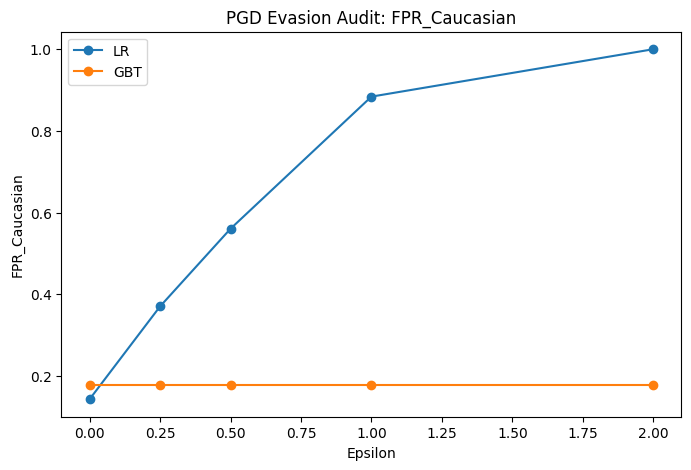

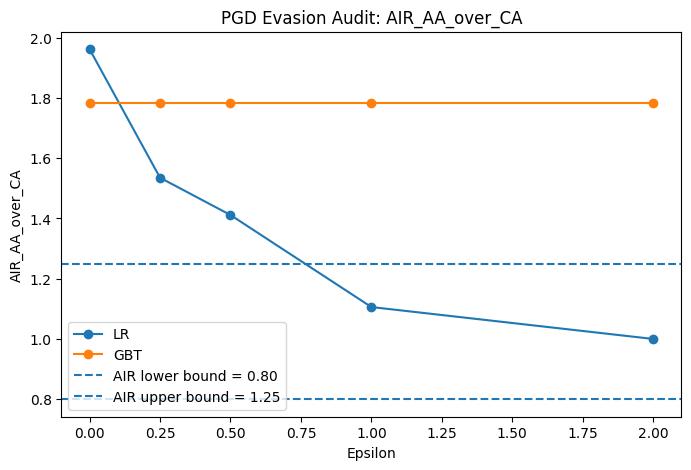

In [5]:
# ── Plot PGD results ─────────────────────────────────────────────────────────

for metric in ['FPR_African_American', 'FPR_Caucasian', 'AIR_AA_over_CA']:
    plt.figure(figsize=(8, 5))

    for model_name in ['LR', 'GBT']:
        sub = df_pgd[df_pgd['model'] == model_name]
        plt.plot(sub['epsilon'], sub[metric], marker='o', label=model_name)

    if metric == 'AIR_AA_over_CA':
        plt.axhline(0.80, linestyle='--', label='AIR lower bound = 0.80')
        plt.axhline(1.25, linestyle='--', label='AIR upper bound = 1.25')

    plt.title(f'PGD Evasion Audit: {metric}')
    plt.xlabel('Epsilon')
    plt.ylabel(metric)
    plt.legend()
    plt.show()

In [6]:
# ── Identify epsilon where AIR crosses 0.80 ──────────────────────────────────

for model_name in ['LR', 'GBT']:
    sub = df_pgd[(df_pgd['model'] == model_name) & (df_pgd['epsilon'] > 0)]

    crossed = sub[sub['AIR_AA_over_CA'] < 0.80]

    if len(crossed) > 0:
        first_eps = crossed.iloc[0]['epsilon']
        print(f"{model_name}: AIR first crosses below 0.80 at epsilon = {first_eps}")
    else:
        print(f"{model_name}: AIR does not cross below 0.80 in tested epsilons.")

LR: AIR does not cross below 0.80 in tested epsilons.
GBT: AIR does not cross below 0.80 in tested epsilons.


**note**

The AIR does not fall below 0.80 for either model within the tested ε range, indicating that the attack does not create adverse impact according to the 80% rule. However, this does not imply fairness, as overall error rates become extremely high under attack.

**Part 1 - PGD Evasion Audit**

The PGD evasion audit shows that Logistic Regression is highly sensitive to adversarial perturbations. As ε increases, the false positive rates for both African-American and Caucasian groups rise sharply, eventually reaching 1.0. This indicates that the model becomes unstable under attack and begins to classify nearly all individuals as high risk. The AIR decreases from 1.96 toward 1.00, suggesting that disparity is reduced, but this is not a desirable outcome because it is achieved by uniformly poor predictions rather than improved fairness.

In contrast, the Gradient Boosted Tree model shows almost no change across all ε values. Both FPR and AIR remain constant, indicating that the PGD attack does not successfully perturb the model. However, this should not be interpreted as true robustness. Instead, it reflects the limitation of gradient-based attacks on non-differentiable models such as decision trees. Because GBT relies on discrete splits rather than smooth gradients, small perturbations in the input space do not effectively change predictions.

Overall, the two models are not equally vulnerable. Logistic Regression is clearly more sensitive to adversarial perturbation, while GBT appears resistant under this attack. However, in high-stakes deployment, this result implies that robustness evaluation must consider multiple attack types. A model that appears robust under one attack may still be vulnerable under a different threat model.

### Part A · Cell 4: Visualize PGD Disparate Impact

**Discussion questions:**
1. Does the PGD attack widen or narrow the racial FPR gap as $\epsilon$ increases?
2. At what $\epsilon$ does the AIR fall below the 4/5ths rule threshold (0.80)?
3. Are the two groups equally sensitive to the same attack strength?
4. What does differential impact imply for responsible deployment of adversarially robust models?

In [7]:
df_pgd = df_pgd.rename(columns={'AIR_AA_over_CA': 'AIR'})

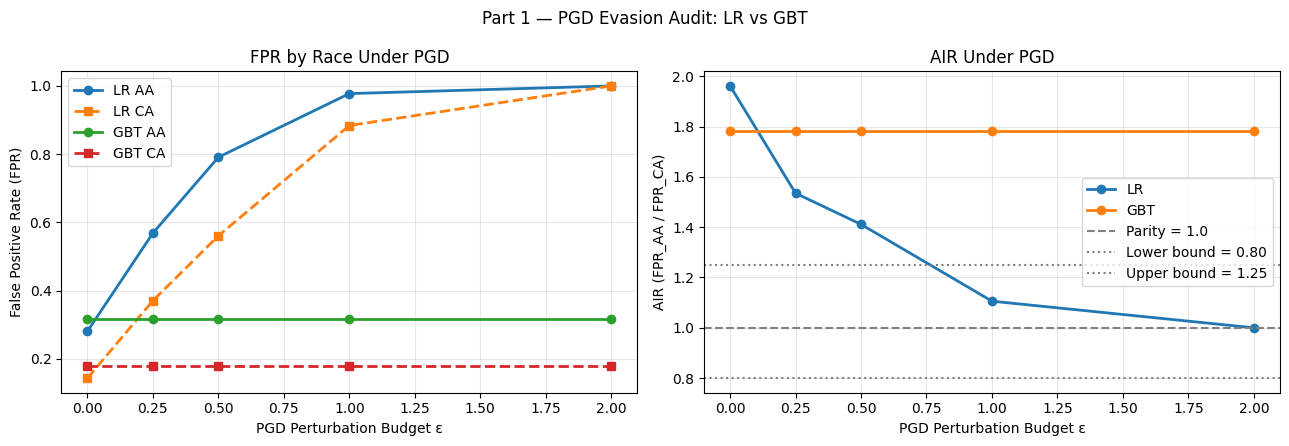

LR: AIR does not fall below 0.80 within the tested epsilon range.
GBT: AIR does not fall below 0.80 within the tested epsilon range.


In [8]:
# ── Cell 4: Visualize PGD Evasion ───────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel 1: FPR by race
ax = axes[0]
for model_name in ['LR', 'GBT']:
    sub = df_pgd[df_pgd['model'] == model_name]
    ax.plot(sub['epsilon'], sub['FPR_African_American'],
            marker='o', lw=2, label=f'{model_name} AA')
    ax.plot(sub['epsilon'], sub['FPR_Caucasian'],
            marker='s', lw=2, linestyle='--', label=f'{model_name} CA')

ax.set_xlabel('PGD Perturbation Budget ε')
ax.set_ylabel('False Positive Rate (FPR)')
ax.set_title('FPR by Race Under PGD')
ax.legend()
ax.grid(alpha=0.3)

# Panel 2: AIR
ax = axes[1]
for model_name in ['LR', 'GBT']:
    sub = df_pgd[df_pgd['model'] == model_name]
    ax.plot(sub['epsilon'], sub['AIR'],
            marker='o', lw=2, label=model_name)

ax.axhline(1.0, color='gray', linestyle='--', label='Parity = 1.0')
ax.axhline(0.80, color='gray', linestyle=':', label='Lower bound = 0.80')
ax.axhline(1.25, color='gray', linestyle=':', label='Upper bound = 1.25')
ax.set_xlabel('PGD Perturbation Budget ε')
ax.set_ylabel('AIR (FPR_AA / FPR_CA)')
ax.set_title('AIR Under PGD')
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle('Part 1 — PGD Evasion Audit: LR vs GBT')
plt.tight_layout()
plt.show()

# Crossover point
for model_name in ['LR', 'GBT']:
    sub = df_pgd[df_pgd['model'] == model_name]
    cross = sub[sub['AIR'] < 0.80].head(1)

    if len(cross):
        print(f"{model_name}: AIR crosses 0.80 at ε = {cross.iloc[0]['epsilon']:.2f}")
    else:
        print(f"{model_name}: AIR does not fall below 0.80 within the tested epsilon range.")

---
## Part B · Cell 5: Data Poisoning — Label-Flip Attack Loop

**Attack class (NIST AI 100-2, §2.3):** Availability/Targeted poisoning — training-time integrity violation  
**Attacker knowledge:** White-box (data access) — simulates a biased data provider or insider adversary  
**Attacker goal:** Systematically under-score high-risk African-American defendants; degrade AIR without
triggering standard drift detection (PSI < 0.10)

### Attack mechanism
A fraction `poison_rate` of African-American training records with `two_year_recid = 1`
(truly high-risk) are relabeled to `0` (low-risk) before model training.
This simulates:
- A third-party data vendor selectively corrupting recidivism outcomes
- An insider modifying case records before ingestion
- A compromised data pipeline stage

> **Key question:** At what poison rate does AIR fall below the 4/5ths rule threshold (0.80)
> while AUC declines by ≤ 2 percentage points — i.e., the attack is "invisible" to AUC monitoring?

In [9]:
# ── Cell 5: Data Poisoning — Label-Flip Attack ───────────────────────────────

def poison_label_flip(
    y_train, race_train,
    poison_rate=0.05,
    target_race='African-American',
    seed=42
):
    """
    Label-flip poisoning attack.

    Flips a fraction of target-race training labels from 1 to 0.
    """
    rng = np.random.default_rng(seed)
    y_poisoned = y_train.copy()

    candidates = np.where(
        (race_train == target_race) & (y_train == 1)
    )[0]

    n_flip = int(len(candidates) * poison_rate)

    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_poisoned[flip_idx] = 0

    return y_poisoned, n_flip


# ── Sweep poison rates for BOTH target groups ────────────────────────────────

poison_rates = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
poison_records = []

baseline_auc = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:, 1])

for target in ['African-American', 'Caucasian']:
    for rate in poison_rates:

        y_tr_poisoned, n_flipped = poison_label_flip(
            y_tr,
            r_tr,
            poison_rate=rate,
            target_race=target,
            seed=42
        )

        lr_p = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr_poisoned)

        probs_p = lr_p.predict_proba(Xs_te)[:, 1]
        pred_p = (probs_p >= THR).astype(int)

        auc_p = roc_auc_score(y_te, probs_p)
        fpr_p = fpr_by_group(y_te, pred_p, r_te)

        aa = fpr_p.get('African-American', np.nan)
        ca = fpr_p.get('Caucasian', np.nan)
        air_p = air(ca, aa)

        poison_records.append({
            'target_group': target,
            'poison_rate': rate,
            'n_flipped': n_flipped,
            'AUC': auc_p,
            'delta_AUC': auc_p - baseline_auc,
            'FPR_AA': aa,
            'FPR_CA': ca,
            'AIR': air_p,
            'delta_AIR': air_p - BASELINE_AIR
        })

df_poison = pd.DataFrame(poison_records)

print("Poisoning sweep results:")
print(df_poison.round(3).to_string(index=False))

Poisoning sweep results:
    target_group  poison_rate  n_flipped   AUC  delta_AUC  FPR_AA  FPR_CA   AIR  delta_AIR
African-American         0.00          0 0.735      0.000   0.281   0.143 1.961      0.000
African-American         0.02         23 0.734     -0.000   0.270   0.133 2.022      0.061
African-American         0.05         57 0.735      0.000   0.231   0.123 1.875     -0.087
African-American         0.08         92 0.734     -0.001   0.216   0.111 1.942     -0.020
African-American         0.10        115 0.733     -0.002   0.200   0.104 1.929     -0.033
African-American         0.15        172 0.733     -0.002   0.153   0.072 2.134      0.173
African-American         0.20        230 0.728     -0.006   0.128   0.054 2.358      0.397
African-American         0.25        287 0.729     -0.006   0.112   0.047 2.395      0.434
African-American         0.30        345 0.731     -0.004   0.099   0.035 2.860      0.899
       Caucasian         0.00          0 0.735      0.000   0.281

In [10]:
# ── Identify stealth zone for BOTH attacks ───────────────────────────────────

for target in ['African-American', 'Caucasian']:
    sub = df_poison[df_poison['target_group'] == target]

    stealth = sub[
        (sub['delta_AUC'] >= -0.02) &
        ((sub['AIR'] < 0.80) | (sub['AIR'] > 1.25))
    ]

    print(f"\nStealth zone for target = {target}:")

    if len(stealth):
        print(
            stealth[['poison_rate', 'n_flipped', 'AUC', 'delta_AUC', 'AIR']]
            .round(3)
            .to_string(index=False)
        )
    else:
        print("No stealth zone found in tested range.")


Stealth zone for target = African-American:
 poison_rate  n_flipped   AUC  delta_AUC   AIR
        0.00          0 0.735      0.000 1.961
        0.02         23 0.734     -0.000 2.022
        0.05         57 0.735      0.000 1.875
        0.08         92 0.734     -0.001 1.942
        0.10        115 0.733     -0.002 1.929
        0.15        172 0.733     -0.002 2.134
        0.20        230 0.728     -0.006 2.358
        0.25        287 0.729     -0.006 2.395
        0.30        345 0.731     -0.004 2.860

Stealth zone for target = Caucasian:
 poison_rate  n_flipped   AUC  delta_AUC   AIR
        0.00          0 0.735      0.000 1.961
        0.02         11 0.735      0.000 1.983
        0.05         29 0.733     -0.001 2.061
        0.08         46 0.733     -0.001 2.043
        0.10         58 0.734     -0.001 1.929
        0.15         87 0.734     -0.001 1.840
        0.20        116 0.733     -0.002 1.880
        0.25        145 0.733     -0.002 1.800
        0.30        174 

### Part B · Cell 6: Poisoning Degradation Curves

**Discussion questions:**
1. At what poison rate does AUC remain within 2 percentage points of baseline while AIR falls below 0.80?
2. Would a PSI-based drift monitor (threshold < 0.10 on each feature) detect this attack?
3. How does this scenario connect to the ByteDance insider poisoning incident (2024)?
4. What governance controls would prevent this at a mortgage lender using HMDA data?

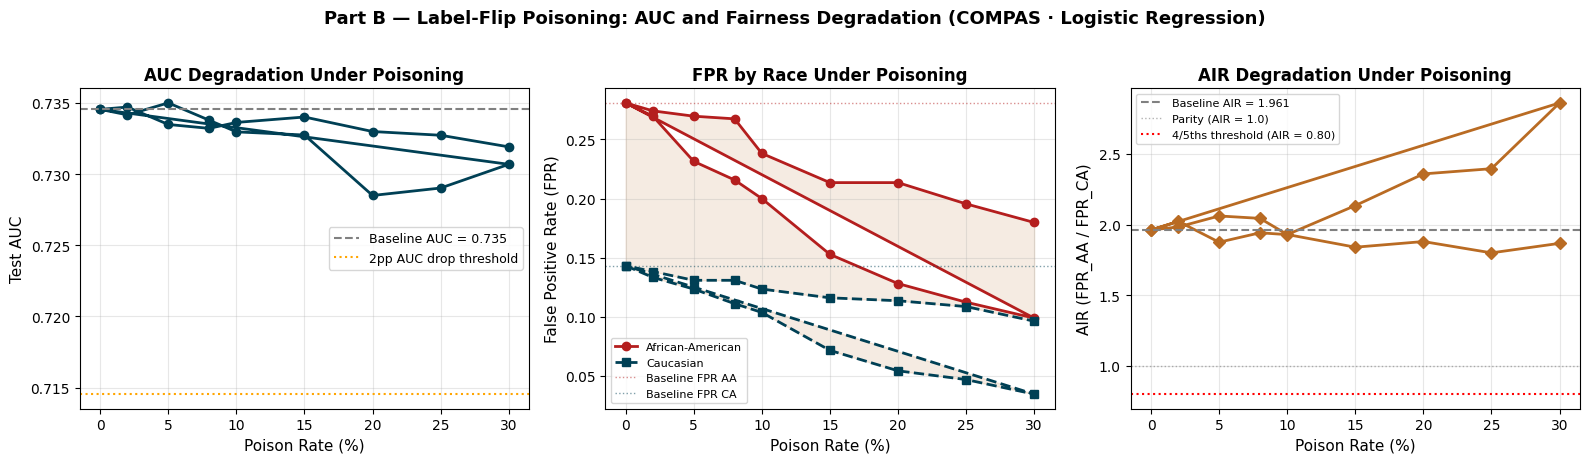

In [11]:
# ── Cell 6: Poisoning Degradation Curves ──────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
x_pct = df_poison['poison_rate'] * 100

# ── Panel 1: AUC degradation ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(x_pct, df_poison['AUC'], 'o-', color='#004055', lw=2)
ax.axhline(baseline_auc,         color='gray', ls='--', lw=1.5,
           label=f'Baseline AUC = {baseline_auc:.3f}')
ax.axhline(baseline_auc - 0.02,  color='orange', ls=':', lw=1.5,
           label='2pp AUC drop threshold')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('Test AUC', fontsize=11)
ax.set_title('AUC Degradation Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Panel 2: FPR by race ──────────────────────────────────────────────────────
ax = axes[1]
ax.plot(x_pct, df_poison['FPR_AA'],
        'o-', color='#B41E1E', lw=2, label='African-American')
ax.plot(x_pct, df_poison['FPR_CA'],
        's--', color='#004055', lw=2, label='Caucasian')
ax.fill_between(x_pct, df_poison['FPR_AA'], df_poison['FPR_CA'],
                alpha=0.13, color='#B96B23')
ax.axhline(BASELINE_AA, color='#B41E1E', ls=':', lw=1, alpha=0.5,
           label='Baseline FPR AA')
ax.axhline(BASELINE_CA, color='#004055', ls=':', lw=1, alpha=0.5,
           label='Baseline FPR CA')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('False Positive Rate (FPR)', fontsize=11)
ax.set_title('FPR by Race Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 3: AIR ──────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(x_pct, df_poison['AIR'], 'D-', color='#B96B23', lw=2)
ax.axhline(BASELINE_AIR, color='gray',  ls='--', lw=1.5,
           label=f'Baseline AIR = {BASELINE_AIR:.3f}')
ax.axhline(1.0,           color='gray',  ls=':',  lw=1.0, alpha=0.6,
           label='Parity (AIR = 1.0)')
ax.axhline(0.8,           color='red',   ls=':',  lw=1.5,
           label='4/5ths threshold (AIR = 0.80)')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('AIR (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR Degradation Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(
    'Part B — Label-Flip Poisoning: AUC and Fairness Degradation (COMPAS · Logistic Regression)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

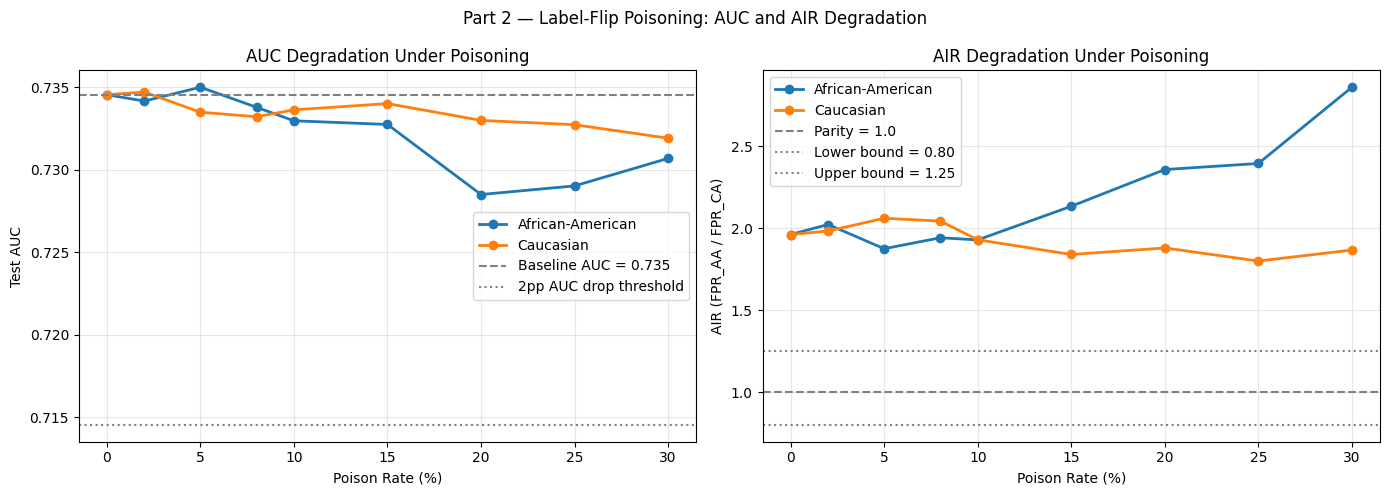

In [12]:
# ── Cell 6: Poisoning Degradation Curves — BOTH target groups ────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: AUC degradation
ax = axes[0]
for target in ['African-American', 'Caucasian']:
    sub = df_poison[df_poison['target_group'] == target]
    ax.plot(sub['poison_rate'] * 100, sub['AUC'], marker='o', lw=2, label=target)

ax.axhline(baseline_auc, color='gray', linestyle='--', label=f'Baseline AUC = {baseline_auc:.3f}')
ax.axhline(baseline_auc - 0.02, color='gray', linestyle=':', label='2pp AUC drop threshold')
ax.set_xlabel('Poison Rate (%)')
ax.set_ylabel('Test AUC')
ax.set_title('AUC Degradation Under Poisoning')
ax.legend()
ax.grid(alpha=0.3)

# Panel 2: AIR degradation
ax = axes[1]
for target in ['African-American', 'Caucasian']:
    sub = df_poison[df_poison['target_group'] == target]
    ax.plot(sub['poison_rate'] * 100, sub['AIR'], marker='o', lw=2, label=target)

ax.axhline(1.0, color='gray', linestyle='--', label='Parity = 1.0')
ax.axhline(0.80, color='gray', linestyle=':', label='Lower bound = 0.80')
ax.axhline(1.25, color='gray', linestyle=':', label='Upper bound = 1.25')
ax.set_xlabel('Poison Rate (%)')
ax.set_ylabel('AIR (FPR_AA / FPR_CA)')
ax.set_title('AIR Degradation Under Poisoning')
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle('Part 2 — Label-Flip Poisoning: AUC and AIR Degradation')
plt.tight_layout()
plt.show()

**Part 2 - Poisoning Loop with Fairness Monitoring**

The poisoning experiment shows that fairness can be manipulated independently of overall model performance. Across all poison rates, the AUC remains relatively stable around 0.73, with a decline of less than 2 percentage points. This indicates that the attack is stealthy and would not be detected by standard performance monitoring.

However, the fairness metric (AIR) behaves very differently depending on the targeted group. When African-American defendants are targeted, the AIR increases significantly from approximately 2.0 to nearly 3.0, indicating worsening disparity. This means the model becomes increasingly biased against African-American individuals.

In contrast, when Caucasian defendants are targeted, the AIR decreases slightly, but remains above the fairness threshold of 1.25. This shows that the direction of bias can be influenced by the attacker, even if the model does not become fully fair.

The stealth zone occurs at low poison rates where the AUC drop is within 2 percentage points while AIR is already outside the acceptable range [0.80, 1.25]. This is particularly concerning because the model appears stable and accurate while fairness is significantly compromised.

A PSI-based drift monitor would likely fail to detect this attack because the poisoning modifies labels rather than feature distributions. Since PSI measures changes in input features, it would not detect this form of manipulation, even as fairness degrades substantially.

---
## Part C · Cell 7: Membership Inference — Shadow Model Pipeline

**Attack class (NIST AI 100-2, §2.4.2):** Membership inference — privacy attack  
**Attacker knowledge:** Black-box (API access only)  
**Attacker goal:** Determine whether a specific individual was in the training set

### Algorithm: Shokri et al. (2017) Shadow Model Attack

1. Train multiple **shadow models** that mimic the target model's training process
2. For each shadow model, we know which inputs were training members vs. non-members
3. Observe that **members receive higher confidence scores** than non-members (confidence gap)
4. Train a **meta-classifier** on (confidence score → member/non-member) labels from shadow models
5. Apply the meta-classifier to the **target model's** confidence scores

> **Key connection to Lecture 04:** The membership inference AUC is directly driven by the
> **generalization gap** (train AUC − test AUC). An overfit model leaks more about its training data.
> Overfitting is not only a robustness problem — it is a **privacy problem**.

In [13]:
# ── Cell 7: Membership Inference — Shadow Model Pipeline ──────────────────────

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedShuffleSplit

N_SHADOW = 10  # number of shadow models

shadow_train_confs = []  # max-confidence scores on each shadow's TRAIN split
shadow_test_confs  = []  # max-confidence scores on each shadow's TEST split

# Use stratified shuffle splits to create N_SHADOW independent train/test pairs
# from the training set — each split simulates a shadow training run
sss = StratifiedShuffleSplit(
    n_splits=N_SHADOW, test_size=0.5, random_state=0
)

print(f"Training {N_SHADOW} shadow models...")
for i, (tr_idx, te_idx) in enumerate(sss.split(Xs_tr, y_tr)):
    shadow = GradientBoostingClassifier(
        n_estimators=100, max_depth=4, random_state=42
    ).fit(Xs_tr[tr_idx], y_tr[tr_idx])

    # Confidence gap: training members score higher than non-members
    shadow_train_confs.append(
        shadow.predict_proba(Xs_tr[tr_idx]).max(axis=1)  # members
    )
    shadow_test_confs.append(
        shadow.predict_proba(Xs_tr[te_idx]).max(axis=1)  # non-members
    )
    if (i + 1) % 5 == 0:
        print(f"  Shadow model {i+1}/{N_SHADOW} trained")

# ── Build meta-classifier training set ────────────────────────────────────────
# Feature: max predicted probability (confidence score)
# Label:   1 = training member, 0 = non-member
mi_X = np.concatenate(
    shadow_train_confs + shadow_test_confs
).reshape(-1, 1)

mi_y = np.concatenate(
    [np.ones(len(c))  for c in shadow_train_confs] +
    [np.zeros(len(c)) for c in shadow_test_confs]
)

meta_clf = DecisionTreeClassifier(max_depth=6).fit(mi_X, mi_y)

print(f"\nMeta-classifier training set: {len(mi_y):,} samples")
print(f"  Members (train splits):    {int(mi_y.sum()):,}")
print(f"  Non-members (test splits): {int((mi_y == 0).sum()):,}")
print("\nMeta-classifier trained. Proceeding to attack the target model...")

Training 10 shadow models...
  Shadow model 5/10 trained
  Shadow model 10/10 trained

Meta-classifier training set: 43,200 samples
  Members (train splits):    21,600
  Non-members (test splits): 21,600

Meta-classifier trained. Proceeding to attack the target model...


### Part C · Cell 8: Membership Inference — ROC Curve and Interpretation

**Interpreting the MI AUC:**
- **0.50** = Random guessing — no privacy leakage detectable
- **0.55–0.65** = Weak leakage — model is somewhat overfit
- **0.65–0.75** = Moderate leakage — meaningful privacy risk
- **> 0.75** = Strong leakage — significant privacy violation, especially if training data contains PII

**Discussion questions:**
1. Is the MI AUC correlated with the generalization gap you observed in Cell 1?
2. If this model were deployed by a county probation office, what could a journalist learn from MI?
3. Would adding differential privacy (ε = 1.0) reduce the MI AUC? At what cost to AIR?
4. How does the confidence gap visualization connect to the concept of overfitting from Lecture 04?

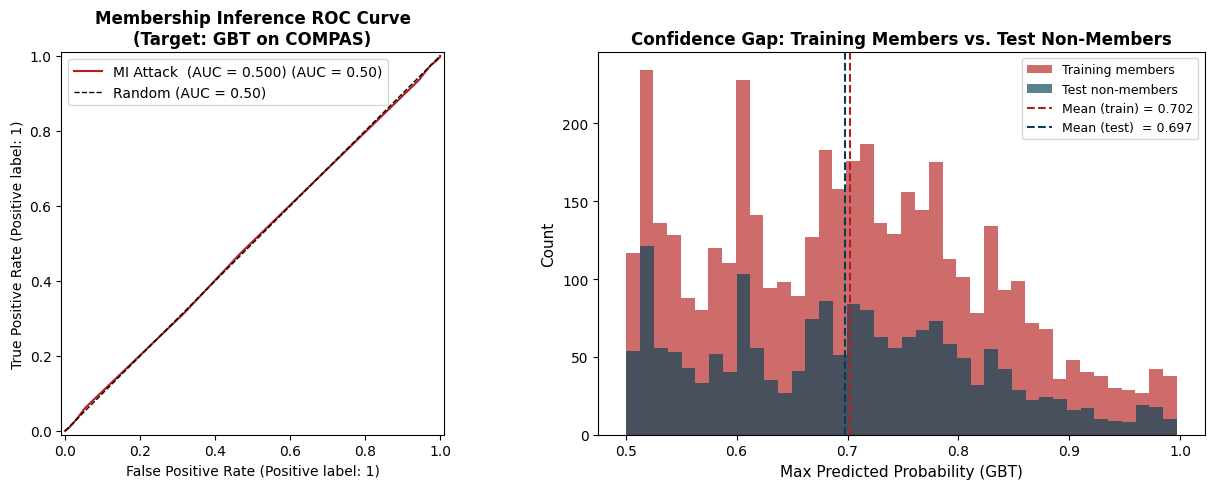

MEMBERSHIP INFERENCE SUMMARY
MI AUC              : 0.500
  0.50 = random     : no privacy leakage
  0.60 = weak       : model somewhat overfit
  0.75 = strong     : significant privacy risk

GBT Train AUC       : 0.798
GBT Test AUC        : 0.718
Generalization Gap  : +0.080

Hypothesis: larger generalization gap → higher MI AUC?
→ Try repeating with the LR model and compare.


In [14]:
# ── Cell 8: Membership Inference — ROC Curve and Interpretation ───────────────

from sklearn.metrics import roc_auc_score, RocCurveDisplay

# ── Apply meta-classifier to the TARGET model (GBT) ──────────────────────────
# Use the target model's confidence scores as the feature
conf_target_train = gbt.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
conf_target_test  = gbt.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)

mi_scores_train = meta_clf.predict_proba(conf_target_train)[:, 1]
mi_scores_test  = meta_clf.predict_proba(conf_target_test)[:, 1]

# Combine: members (train) = 1, non-members (test) = 0
mi_all_scores = np.concatenate([mi_scores_train, mi_scores_test])
mi_all_labels = np.concatenate([
    np.ones(len(Xs_tr)),
    np.zeros(len(Xs_te))
])

mi_auc = roc_auc_score(mi_all_labels, mi_all_scores)

# Generalization gap (privacy risk proxy)
auc_train_gbt = roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:, 1])
auc_test_gbt  = roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:, 1])
gen_gap       = auc_train_gbt - auc_test_gbt

# ── Visualize ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
RocCurveDisplay.from_predictions(
    mi_all_labels, mi_all_scores,
    name=f'MI Attack  (AUC = {mi_auc:.3f})',
    ax=axes[0], color='#B41E1E'
)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.50)')
axes[0].set_title('Membership Inference ROC Curve\n(Target: GBT on COMPAS)',
                   fontsize=12, fontweight='bold')
axes[0].legend()

# Confidence gap histogram
axes[1].hist(conf_target_train.ravel(), bins=40, alpha=0.65,
             color='#B41E1E', label='Training members')
axes[1].hist(conf_target_test.ravel(),  bins=40, alpha=0.65,
             color='#004055', label='Test non-members')
axes[1].axvline(conf_target_train.mean(), color='#B41E1E', ls='--', lw=1.5,
                label=f'Mean (train) = {conf_target_train.mean():.3f}')
axes[1].axvline(conf_target_test.mean(),  color='#004055', ls='--', lw=1.5,
                label=f'Mean (test)  = {conf_target_test.mean():.3f}')
axes[1].set_xlabel('Max Predicted Probability (GBT)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Confidence Gap: Training Members vs. Test Non-Members',
                   fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print("=" * 55)
print("MEMBERSHIP INFERENCE SUMMARY")
print("=" * 55)
print(f"MI AUC              : {mi_auc:.3f}")
print(f"  0.50 = random     : no privacy leakage")
print(f"  0.60 = weak       : model somewhat overfit")
print(f"  0.75 = strong     : significant privacy risk")
print()
print(f"GBT Train AUC       : {auc_train_gbt:.3f}")
print(f"GBT Test AUC        : {auc_test_gbt:.3f}")
print(f"Generalization Gap  : {gen_gap:+.3f}")
print()
print("Hypothesis: larger generalization gap → higher MI AUC?")
print("→ Try repeating with the LR model and compare.")

Membership inference comparison:
Model  MI_AUC  Train_AUC  Test_AUC  Gen_Gap
   LR  0.4943     0.7269    0.7345  -0.0077
  GBT  0.5002     0.7981    0.7179   0.0802


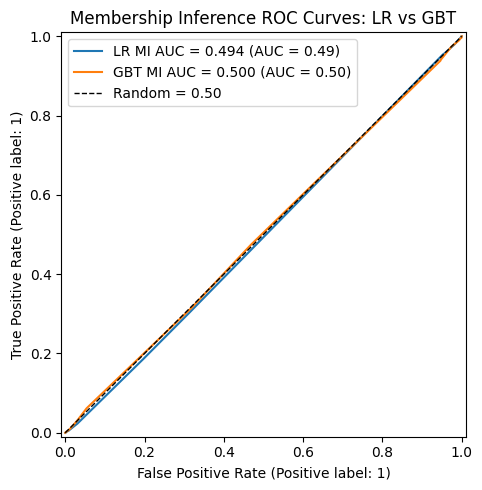

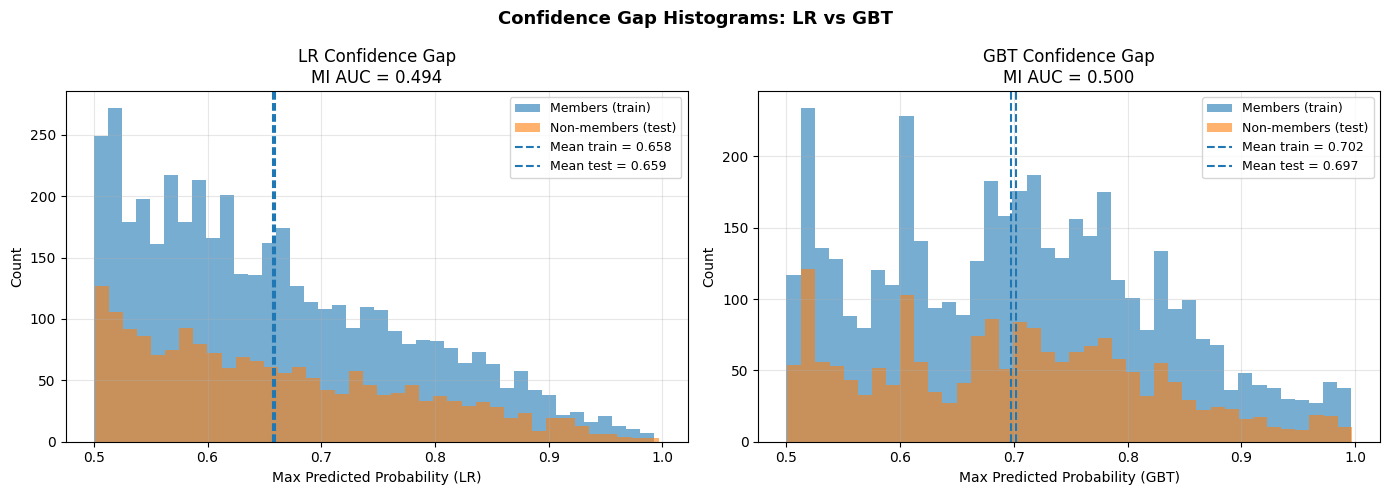

In [15]:
# ── Cell 8: Membership Inference — LR vs GBT ────────────────────────────────

from sklearn.metrics import roc_auc_score, RocCurveDisplay

def membership_attack_summary(model, model_name):
    # Confidence score = max predicted probability
    conf_train = model.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
    conf_test  = model.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)

    # Meta-classifier predicts membership
    mi_scores_train = meta_clf.predict_proba(conf_train)[:, 1]
    mi_scores_test  = meta_clf.predict_proba(conf_test)[:, 1]

    mi_scores = np.concatenate([mi_scores_train, mi_scores_test])
    mi_labels = np.concatenate([
        np.ones(len(conf_train)),
        np.zeros(len(conf_test))
    ])

    mi_auc = roc_auc_score(mi_labels, mi_scores)

    train_auc = roc_auc_score(y_tr, model.predict_proba(Xs_tr)[:, 1])
    test_auc  = roc_auc_score(y_te, model.predict_proba(Xs_te)[:, 1])
    gen_gap = train_auc - test_auc

    return {
        'model': model_name,
        'conf_train': conf_train,
        'conf_test': conf_test,
        'mi_scores': mi_scores,
        'mi_labels': mi_labels,
        'MI_AUC': mi_auc,
        'Train_AUC': train_auc,
        'Test_AUC': test_auc,
        'Gen_Gap': gen_gap
    }


# Run attack on both target models
mi_lr = membership_attack_summary(lr, "LR")
mi_gbt = membership_attack_summary(gbt, "GBT")

mi_compare = pd.DataFrame([
    {
        'Model': mi_lr['model'],
        'MI_AUC': mi_lr['MI_AUC'],
        'Train_AUC': mi_lr['Train_AUC'],
        'Test_AUC': mi_lr['Test_AUC'],
        'Gen_Gap': mi_lr['Gen_Gap']
    },
    {
        'Model': mi_gbt['model'],
        'MI_AUC': mi_gbt['MI_AUC'],
        'Train_AUC': mi_gbt['Train_AUC'],
        'Test_AUC': mi_gbt['Test_AUC'],
        'Gen_Gap': mi_gbt['Gen_Gap']
    }
])

print("Membership inference comparison:")
print(mi_compare.round(4).to_string(index=False))


# ── ROC curves: LR vs GBT ───────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(6, 5))

RocCurveDisplay.from_predictions(
    mi_lr['mi_labels'], mi_lr['mi_scores'],
    name=f"LR MI AUC = {mi_lr['MI_AUC']:.3f}",
    ax=ax
)

RocCurveDisplay.from_predictions(
    mi_gbt['mi_labels'], mi_gbt['mi_scores'],
    name=f"GBT MI AUC = {mi_gbt['MI_AUC']:.3f}",
    ax=ax
)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random = 0.50')
ax.set_title("Membership Inference ROC Curves: LR vs GBT")
ax.legend()
plt.tight_layout()
plt.show()


# ── Confidence gap histograms side by side ──────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, result in zip(axes, [mi_lr, mi_gbt]):
    model_name = result['model']
    conf_train = result['conf_train'].ravel()
    conf_test  = result['conf_test'].ravel()

    ax.hist(conf_train, bins=40, alpha=0.60, label='Members (train)')
    ax.hist(conf_test, bins=40, alpha=0.60, label='Non-members (test)')

    ax.axvline(conf_train.mean(), linestyle='--',
               label=f"Mean train = {conf_train.mean():.3f}")
    ax.axvline(conf_test.mean(), linestyle='--',
               label=f"Mean test = {conf_test.mean():.3f}")

    ax.set_xlabel(f"Max Predicted Probability ({model_name})")
    ax.set_ylabel("Count")
    ax.set_title(f"{model_name} Confidence Gap\nMI AUC = {result['MI_AUC']:.3f}")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Confidence Gap Histograms: LR vs GBT", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Part 3 – Membership Inference**

The membership inference results show that both Logistic Regression (LR) and Gradient Boosted Trees (GBT) have MI AUC values close to 0.50, meaning the attack performs no better than random guessing. The confidence-gap histograms also show strong overlap between training members and test non-members, with nearly identical mean confidence values. This indicates that the models do not assign systematically higher confidence to training data compared to unseen data, resulting in limited membership leakage under this attack.

The generalization gap comparison supports this interpretation. Models that overfit typically exhibit higher training AUC than test AUC, which increases the confidence gap and makes membership inference easier. In this experiment, LR shows almost no generalization gap, while GBT has a small positive gap. However, despite GBT having a slightly larger gap, the confidence distributions still overlap heavily, so the attack remains ineffective.

Overall, these results suggest that both models generalize reasonably well and do not expose significant privacy risk under this shadow-model attack. However, this does not guarantee full privacy protection, as more sophisticated attacks or different model configurations may still lead to information leakage.

---
## Lab Summary

| Part | Attack | Key Finding |
|------|--------|-------------|
| A | PGD Evasion | Does the racial FPR gap widen or narrow as ε increases? Which group is more sensitive? |
| B | Label-Flip Poisoning | At what poison rate does AIR < 0.80 while AUC drop ≤ 2pp? Would drift detection catch it? |
| C | Membership Inference | Is MI AUC correlated with generalization gap? What privacy law implications follow? |

### Core Principle

> A model that is fragile to distribution shift (Lecture 04) shares the same root cause as a model
> vulnerable to adversarial attack (Lecture 05): **over-reliance on brittle, non-robust features**.
> Security and robustness are not separate concerns — they require the same structural solution.

### References
- Vassilev et al. (2024). *NIST AI 100-2e2023.* https://doi.org/10.6028/NIST.AI.100-2e2023
- Goodfellow et al. (2015). Explaining and Harnessing Adversarial Examples. *ICLR 2015.* https://arxiv.org/abs/1412.6572
- Madry et al. (2018). Towards Deep Learning Models Resistant to Adversarial Attacks. *ICLR 2018.* https://arxiv.org/abs/1706.06083
- Shokri et al. (2017). Membership Inference Attacks Against Machine Learning Models. *IEEE S&P.* https://arxiv.org/abs/1610.05820
- Tramèr et al. (2016). Stealing Machine Learning Models via Prediction APIs. *USENIX Security.* https://arxiv.org/abs/1609.02943
- Bagdasaryan & Shmatikov (2019). Differential Privacy Has Disparate Impact on Model Accuracy. *NeurIPS.* https://arxiv.org/abs/1905.12101

---
*DNSC 6330 · Responsible Machine Learning · Dr. Michael Akinwumi · George Washington University*  
*© CC BY 4.0 · https://makinwumi.github.io/dnsc-6330-responsible-ML*